In [27]:
%matplotlib

Using matplotlib backend: agg


In [28]:
from switch_model.tools.graph.main import GraphTools

from papers.Martin_Staadecker_et_al_2022.util import (
    get_scenario
)


tools = GraphTools([get_scenario("1342")], set_style=False)
tools.pre_graphing(multi_scenario=False)

ROLLING_AVERAGE_DAYS = 7
tools

In [29]:
dispatch = tools.get_dataframe(
    "dispatch.csv",
    usecols=[
        "timestamp",
        "gen_tech",
        "gen_energy_source",
        "DispatchGen_MW",
        "Curtailment_MW",
    ],
).rename({"DispatchGen_MW": "dispatch", "Curtailment_MW": "with_curtailment"}, axis=1)
dispatch = tools.transform.gen_type(dispatch)
# Sum dispatch across all the projects of the same type and timepoint
dispatch = dispatch[dispatch["gen_type"] != "Storage"]
dispatch = dispatch.groupby(["timestamp", "gen_type"], as_index=False).sum()
dispatch

,timestamp,gen_type,dispatch,with_curtailment
0,2050010200,Biomass,2781.187860,6088.726270
1,2050010200,Coal,0.000000,1546.360000
2,2050010200,Gas,0.000000,13481.096000
3,2050010200,Geothermal,0.000000,0.000000
4,2050010200,Hydro,45998.584379,14165.778706
...,...,...,...,...
19651,2050123120,Hydro,13617.948158,46546.352666
19652,2050123120,Nuclear,4881.600000,0.000000
19653,2050123120,Solar,280499.973949,4592.068400
19654,2050123120,Waste,0.000000,9.984000


In [30]:

# Get load dataframe
load = tools.get_dataframe(
    "load_balance.csv",
    usecols=["timestamp", "zone_demand_mw"],
).rename({"zone_demand_mw": "value"}, axis=1)
# Sum load across all the load zones
load = load.groupby("timestamp", as_index=False).sum()
# Flip sign
load["value"] *= -1
load

,timestamp,value
0,2050010200,133653.364
1,2050010204,176582.131
2,2050010208,185383.696
3,2050010212,172840.335
4,2050010216,181227.071
...,...,...
2179,2050123104,188550.370
2180,2050123108,206320.999
2181,2050123112,197357.655
2182,2050123116,175203.187


In [31]:
def process_time(df):
    # Add the datetime info like timestamps and PST time
    df = tools.transform.timestamp(df)
    # Filter range so we only get from Jan 2nd to Dec 31st
    df = df[(df["timestamp"] >= 2050010208) & (df["timestamp"] <= 2050123104)]
    # Keep only last period
    df = df.astype({"period": int})
    df = df[df["period"] == df["period"].max()].drop(columns="period")
    df = df.set_index("datetime")
    # Remove unneeded columns
    df = df.drop(
        columns=[
            "hour",
            "timestamp",
            "timepoint",
            "time_row",
            "time_column",
            "season",
            "timeseries",
        ]
    )
    return df


# Add the timestamp information and make period string to ensure it doesn't mess up the graphing
dispatch = process_time(dispatch)
load = process_time(load)

dispatch["dispatch"] *= dispatch["tp_duration"] / 1e6
dispatch["with_curtailment"] *= dispatch["tp_duration"] / 1e6
load["value"] *= load["tp_duration"] / 1e6
dispatch = dispatch.drop(columns="tp_duration")
load = load.drop(columns="tp_duration")

curtailment = (
    dispatch[["gen_type", "with_curtailment"]]
    .copy()
    .rename({"with_curtailment": "value"}, axis=1)
)
dispatch = dispatch[["gen_type", "dispatch"]].rename({"dispatch": "value"}, axis=1)


def rolling_avg(df):
    freq = str(ROLLING_AVERAGE_DAYS) + "D"
    df = df.rolling(freq, center=True).mean()
    return df


dispatch = (
    dispatch.groupby("gen_type").value.resample("D").sum().unstack(level=1).transpose()
)
dispatch = rolling_avg(dispatch)
curtailment = (
    curtailment.groupby("gen_type")
    .value.resample("D")
    .sum()
    .unstack(level=1)
    .transpose()
)
curtailment = rolling_avg(curtailment)
load = load[["value"]].resample("D").sum()
load = rolling_avg(load)
dispatch = dispatch[
    dispatch.columns[dispatch.max() > 1e-3]
]  # Remove techs that don't contribute more than 1GWh/day on any day
curtailment = curtailment[["Wind", "Solar"]]
dispatch = dispatch[dispatch.std().sort_values().index].rename_axis(
    "Technology", axis=1
)

duals = tools.get_dataframe(
    "load_balance.csv",
    usecols=["timestamp", "normalized_energy_balance_duals_dollar_per_mwh"],
).rename(columns={"normalized_energy_balance_duals_dollar_per_mwh": "value"})
duals = duals.groupby(["timestamp"], as_index=False).mean()
duals = process_time(duals).drop(columns=["tp_duration"])
duals = rolling_avg(duals)
dispatch, load, curtailment, duals

(Technology                  Nuclear   Biomass     Hydro     Solar      Wind
 datetime                                                                   
 2050-01-02 00:00:00-08:00  0.117158  0.024503  0.854198  2.313488  1.304166
 2050-01-03 00:00:00-08:00  0.117158  0.019804  0.782978  2.388741  1.333070
 2050-01-04 00:00:00-08:00  0.117158  0.016671  0.756148  2.409738  1.258680
 2050-01-05 00:00:00-08:00  0.117158  0.014433  0.730484  2.452813  1.223273
 2050-01-06 00:00:00-08:00  0.117158  0.004552  0.612540  2.644626  1.268551
 ...                             ...       ...       ...       ...       ...
 2050-12-26 00:00:00-08:00  0.117158  0.205091  0.785045  2.347347  1.129401
 2050-12-27 00:00:00-08:00  0.117158  0.205905  0.791811  2.384721  1.077758
 2050-12-28 00:00:00-08:00  0.117158  0.207840  0.845496  2.358908  1.043082
 2050-12-29 00:00:00-08:00  0.117158  0.209870  0.921810  2.337321  0.914356
 2050-12-30 00:00:00-08:00  0.117158  0.209118  0.875855  2.495845  0.903000

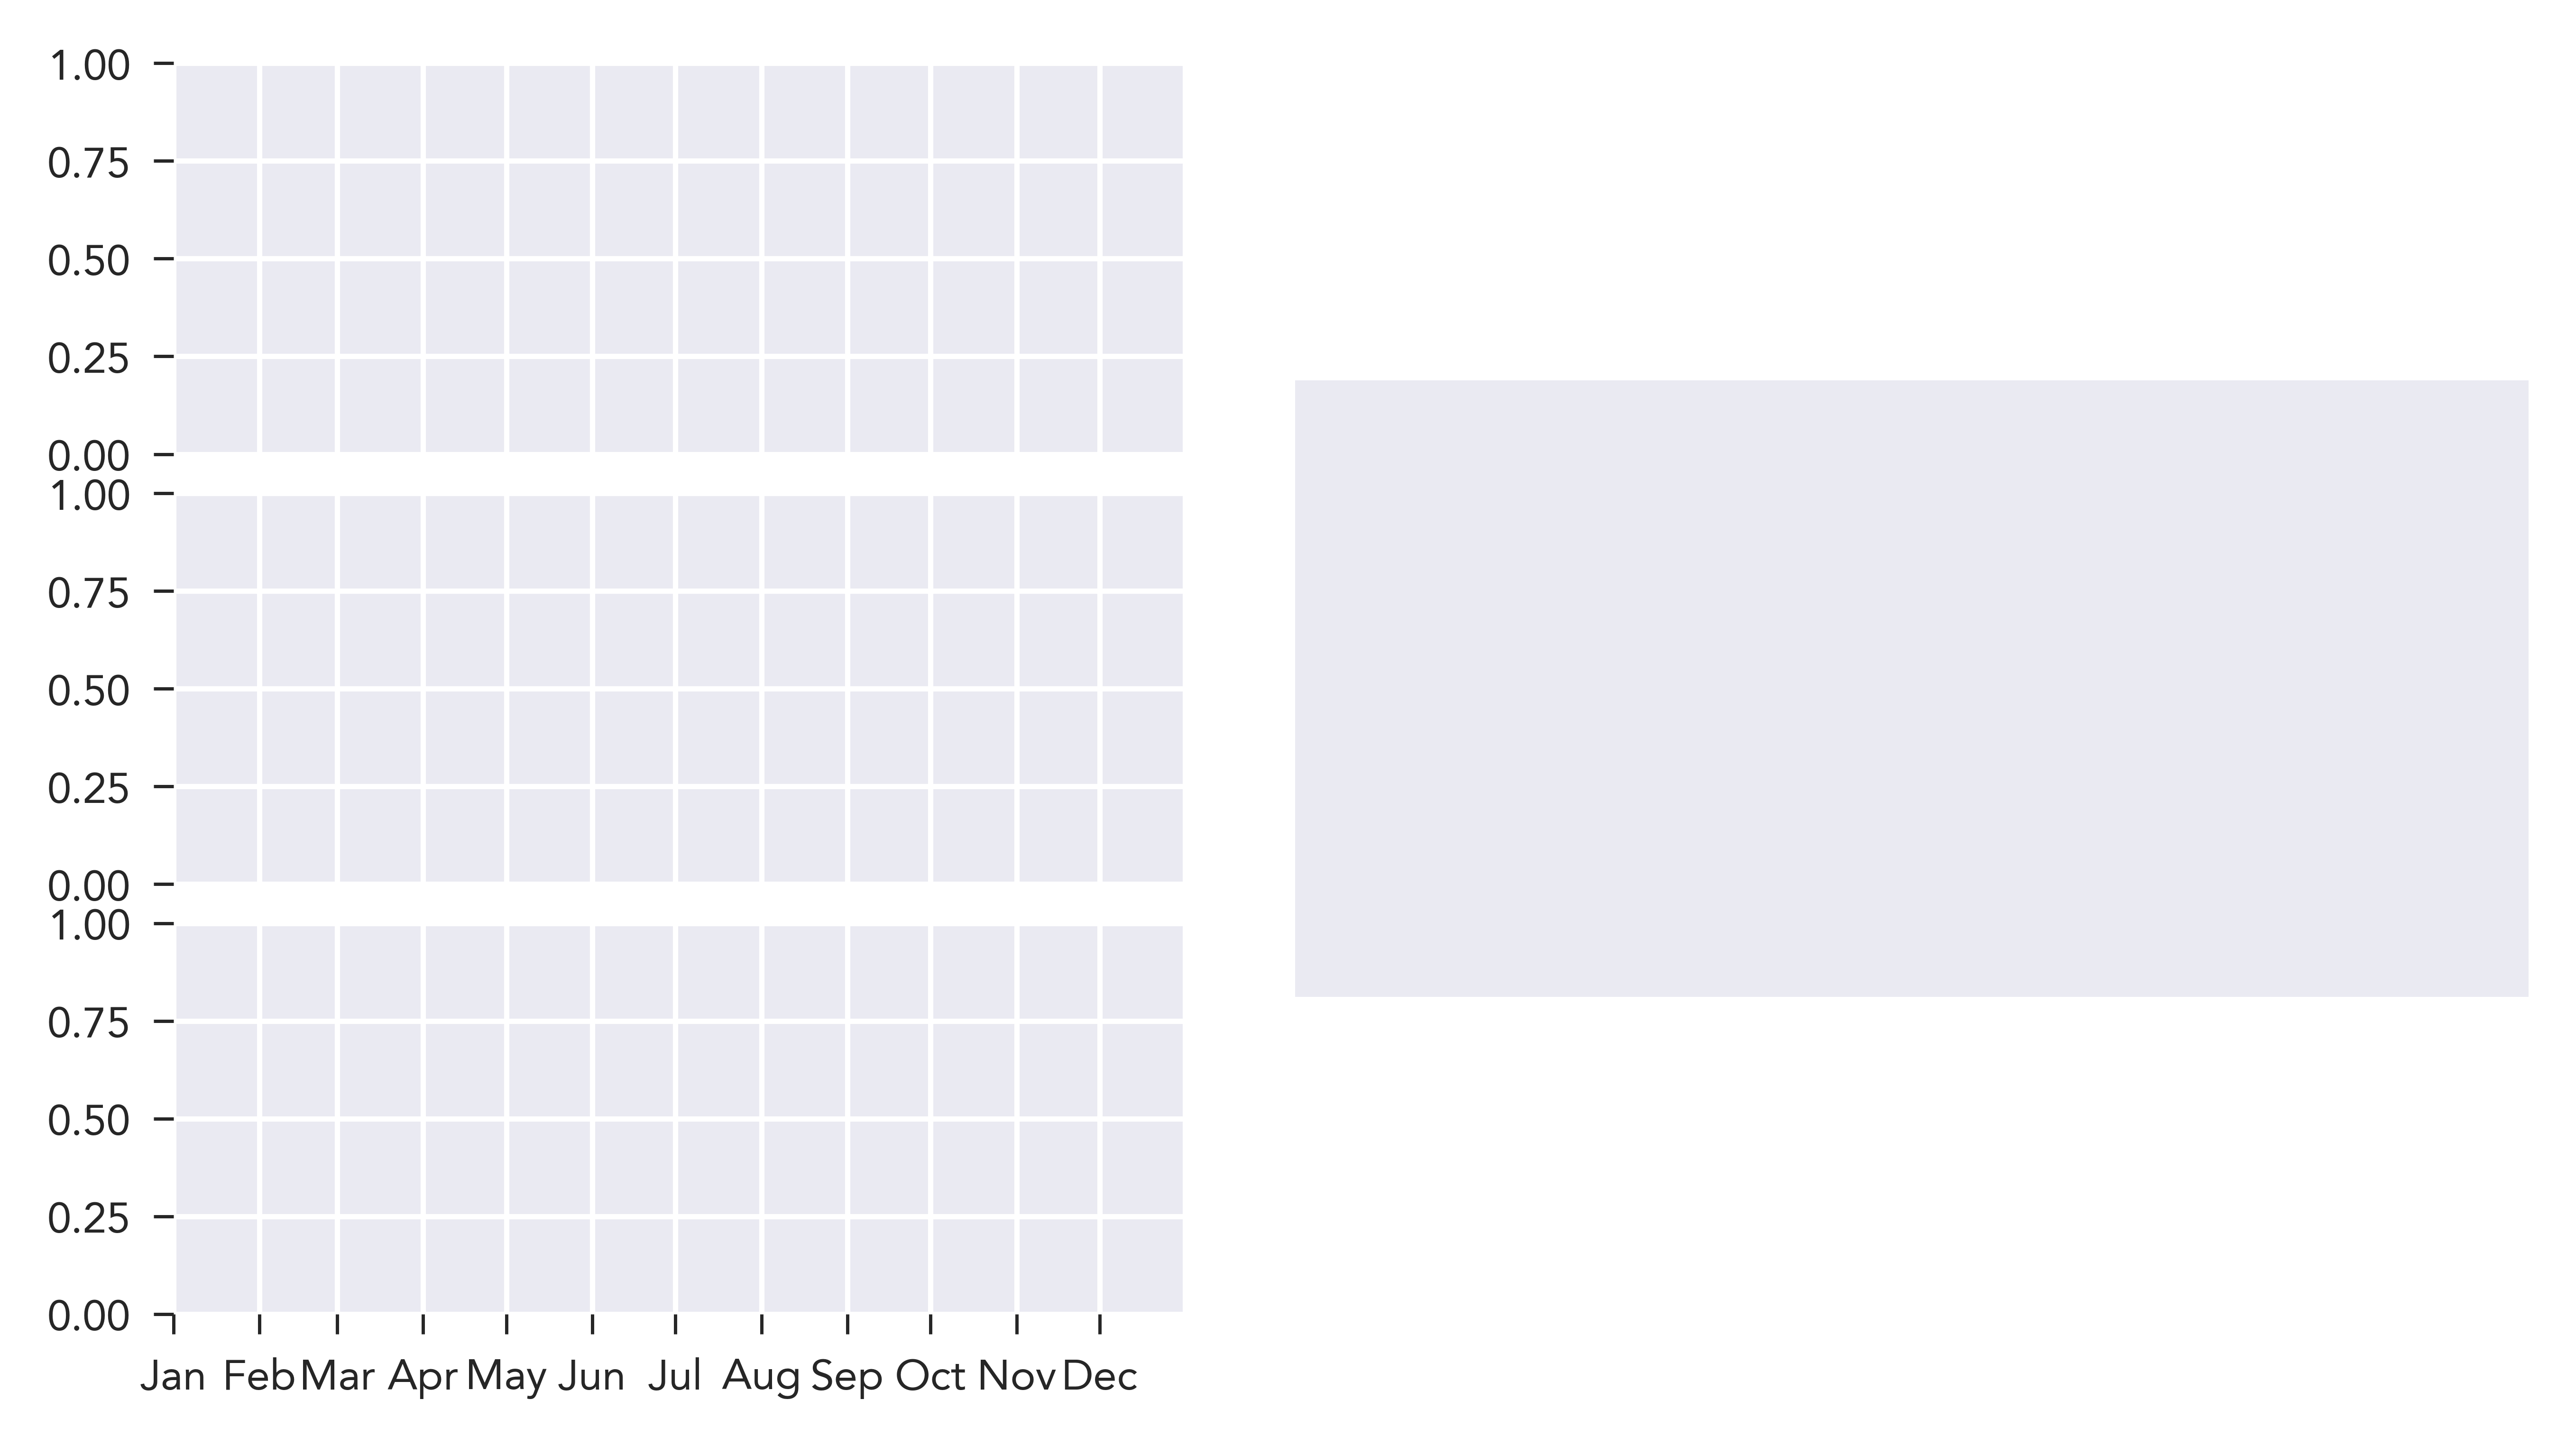

In [32]:
from matplotlib import pyplot as plt
from matplotlib import gridspec
from datetime import datetime
from papers.Martin_Staadecker_et_al_2022.util import set_style
from matplotlib import dates as mdates

set_style()
fig = plt.figure()
gs = gridspec.GridSpec(3, 2, hspace=0.1, wspace=0.1, width_ratios=[0.45, 0.55], right=0.85)
ax1a = fig.add_subplot(gs[0, 0])
ax1a.tick_params('x', which="both", labelbottom=False, bottom=False)
ax1a.tick_params('y', labelleft=True)

ax1b = fig.add_subplot(gs[1, 0], sharex=ax1a)
ax1b.tick_params('x', which="both", labelbottom=False, bottom=False)

ax1c = fig.add_subplot(gs[2, 0], sharex=ax1a)
ax1c.tick_params('x', which="minor", bottom=False)
ax1c.set_xlim([datetime(2050, 1, 1), datetime(2050, 12, 31)])
ax1c.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1c.xaxis.set_major_locator(mdates.MonthLocator())

ax2 = fig.add_subplot(gs[:, 1], projection=tools.maps.get_projection())
fig

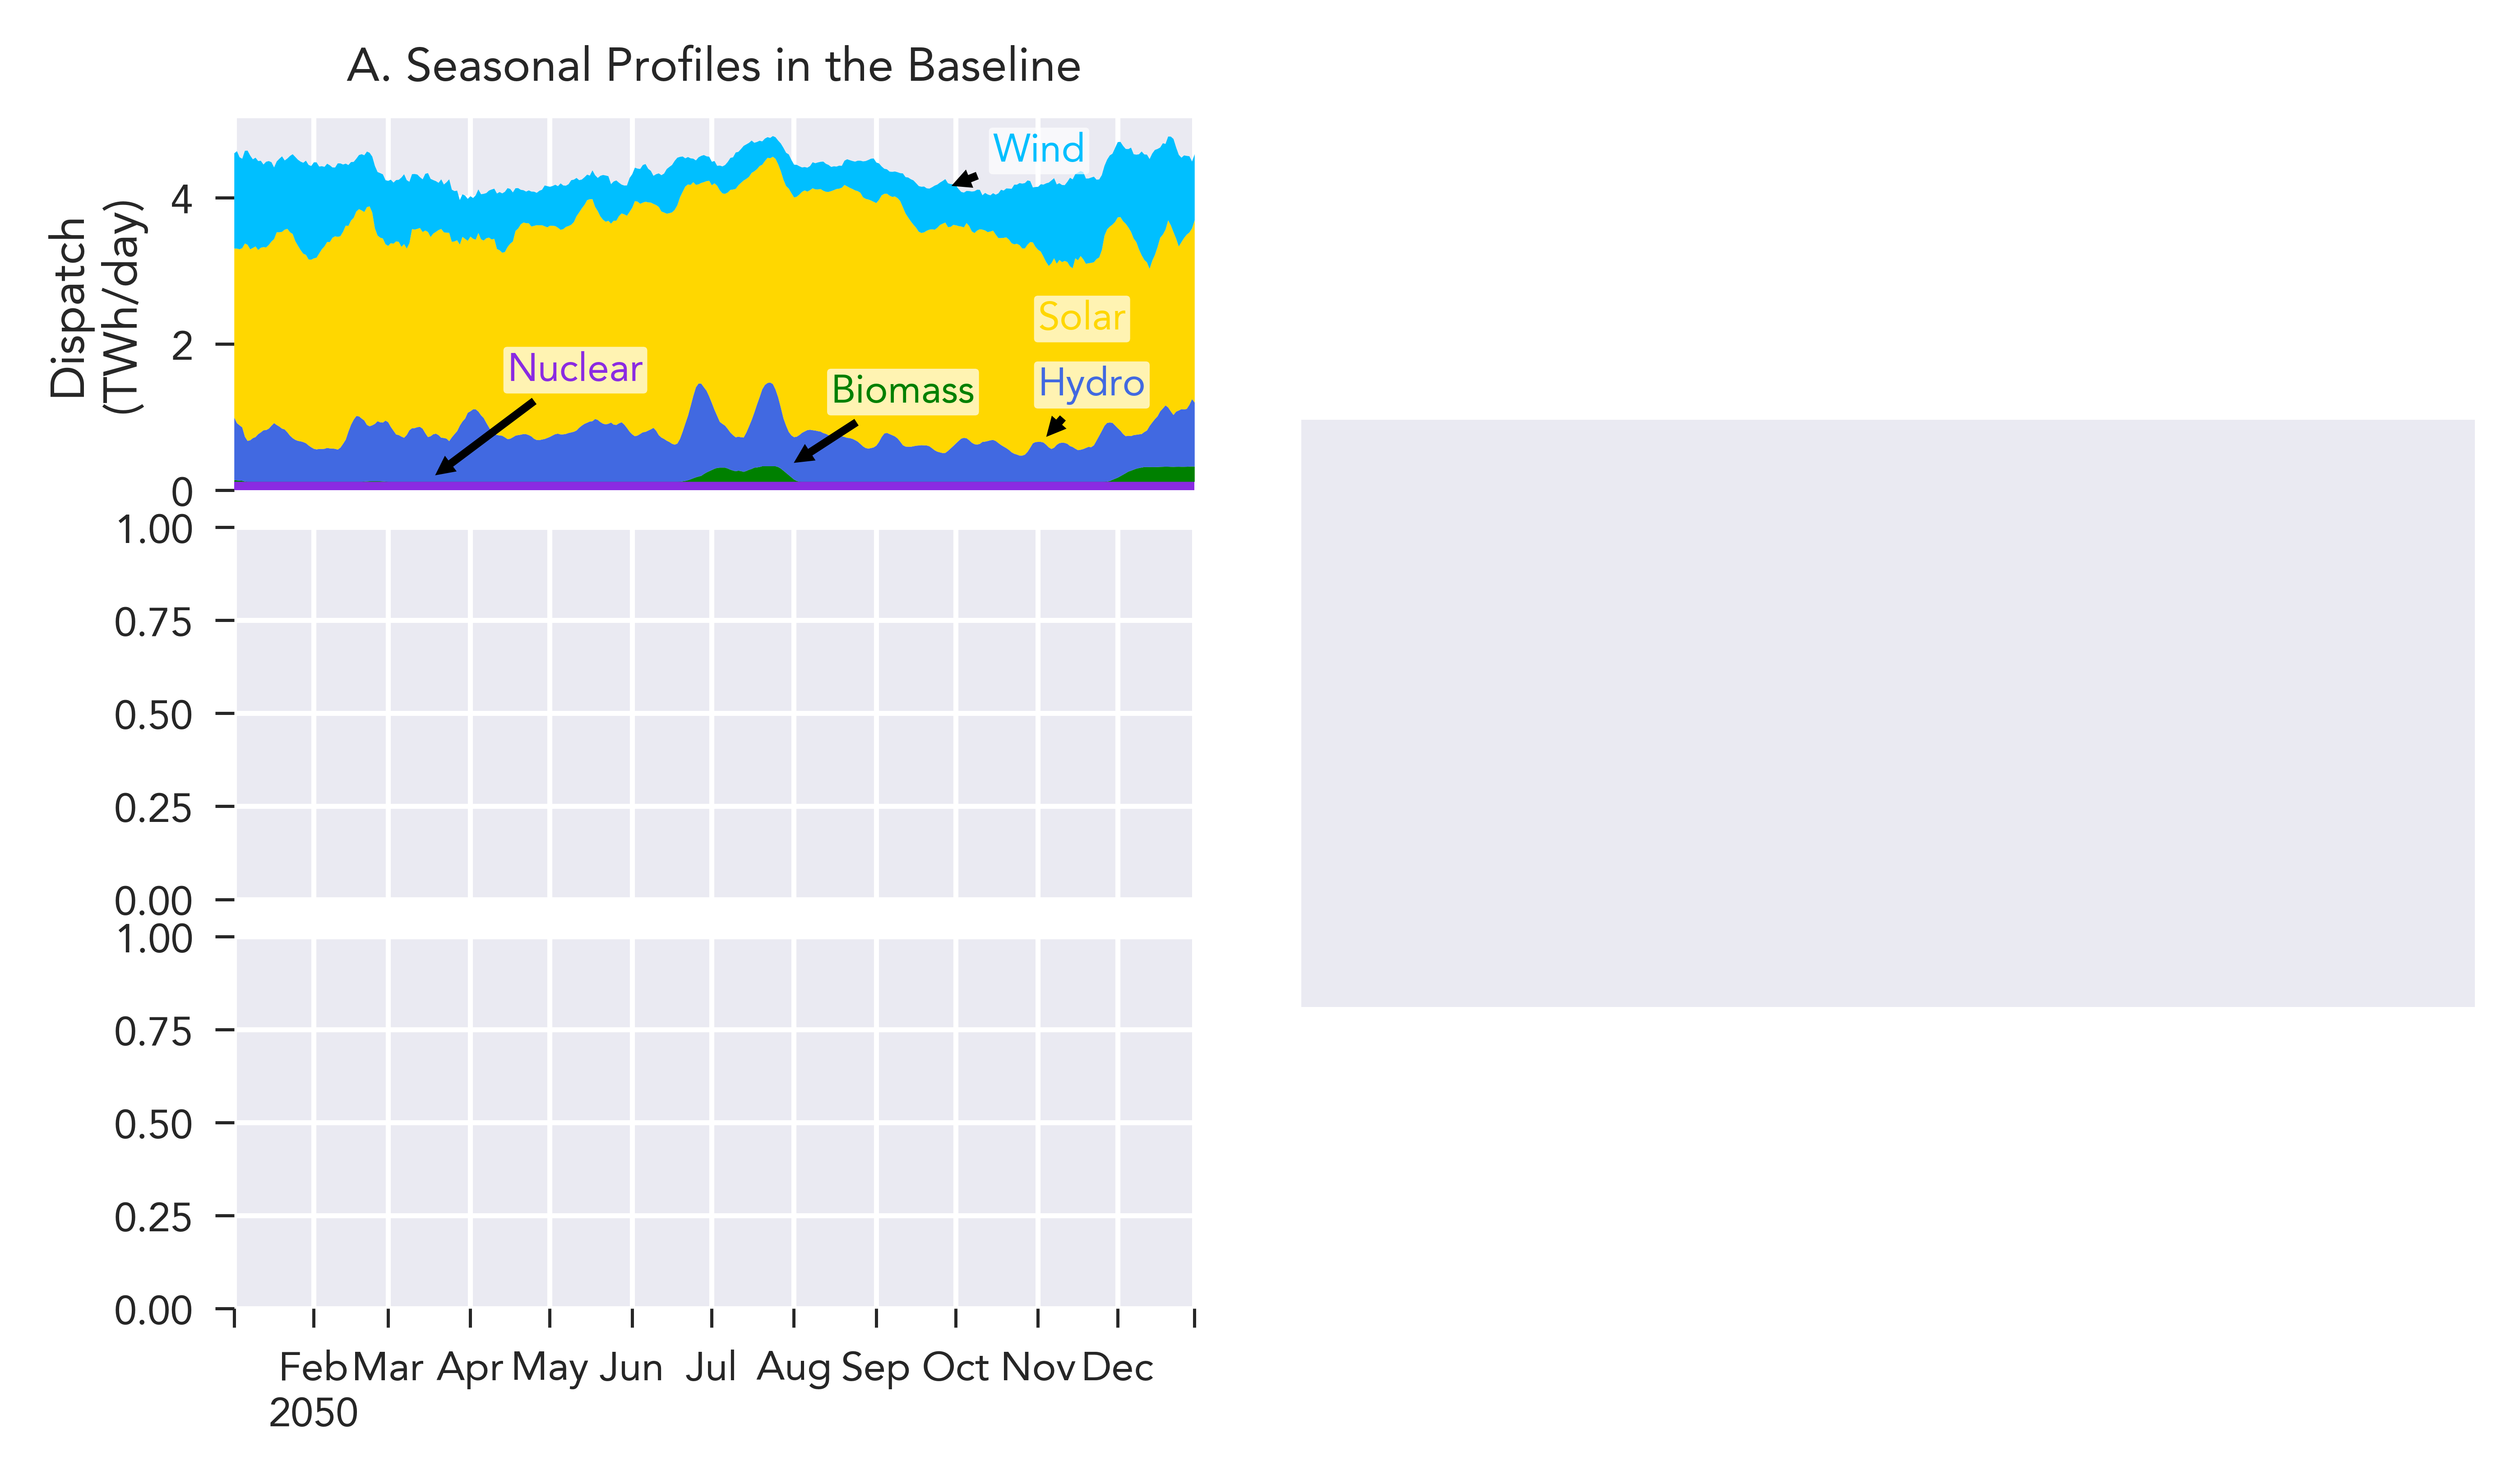

In [33]:
ax = ax1a
ax.clear()
dispatch.plot.area(ax=ax, color=tools.get_colors(), legend=None, linewidth=0)

ax.set_title("A. Seasonal Profiles in the Baseline")
ax.set_ylabel("Dispatch\n(TWh/day)")

poss = {"Solar": (datetime(2050, 11, 1), 2.2), "Wind": (datetime(2050, 10, 15), 4.5),
        "Hydro": (datetime(2050, 11, 1), 1.3),
        "Biomass": (datetime(2050, 8, 15), 1.2), "Nuclear": (datetime(2050, 4, 15), 1.5)}
arrow_poss = {"Biomass": (datetime(2050, 7, 28), 0.28), "Nuclear": (datetime(2050, 3, 15), 0.1),
              "Hydro": (datetime(2050, 11, 1), 0.6), "Wind": (datetime(2050, 9, 25), 4.1)}
colors = tools.get_colors()
for label, pos in poss.items():
    args = dict(
        text=label, color=colors[label], fontsize="small",
        bbox=dict(pad=0.1, color="white", alpha=0.7, linewidth=0, boxstyle="round")
    )
    if label in arrow_poss:
        args["xy"] = arrow_poss[label]
        args["xytext"] = pos
        args["arrowprops"] = dict(facecolor="black", arrowstyle="simple")
    else:
        args["xy"] = pos
    ax.annotate(**args)

fig

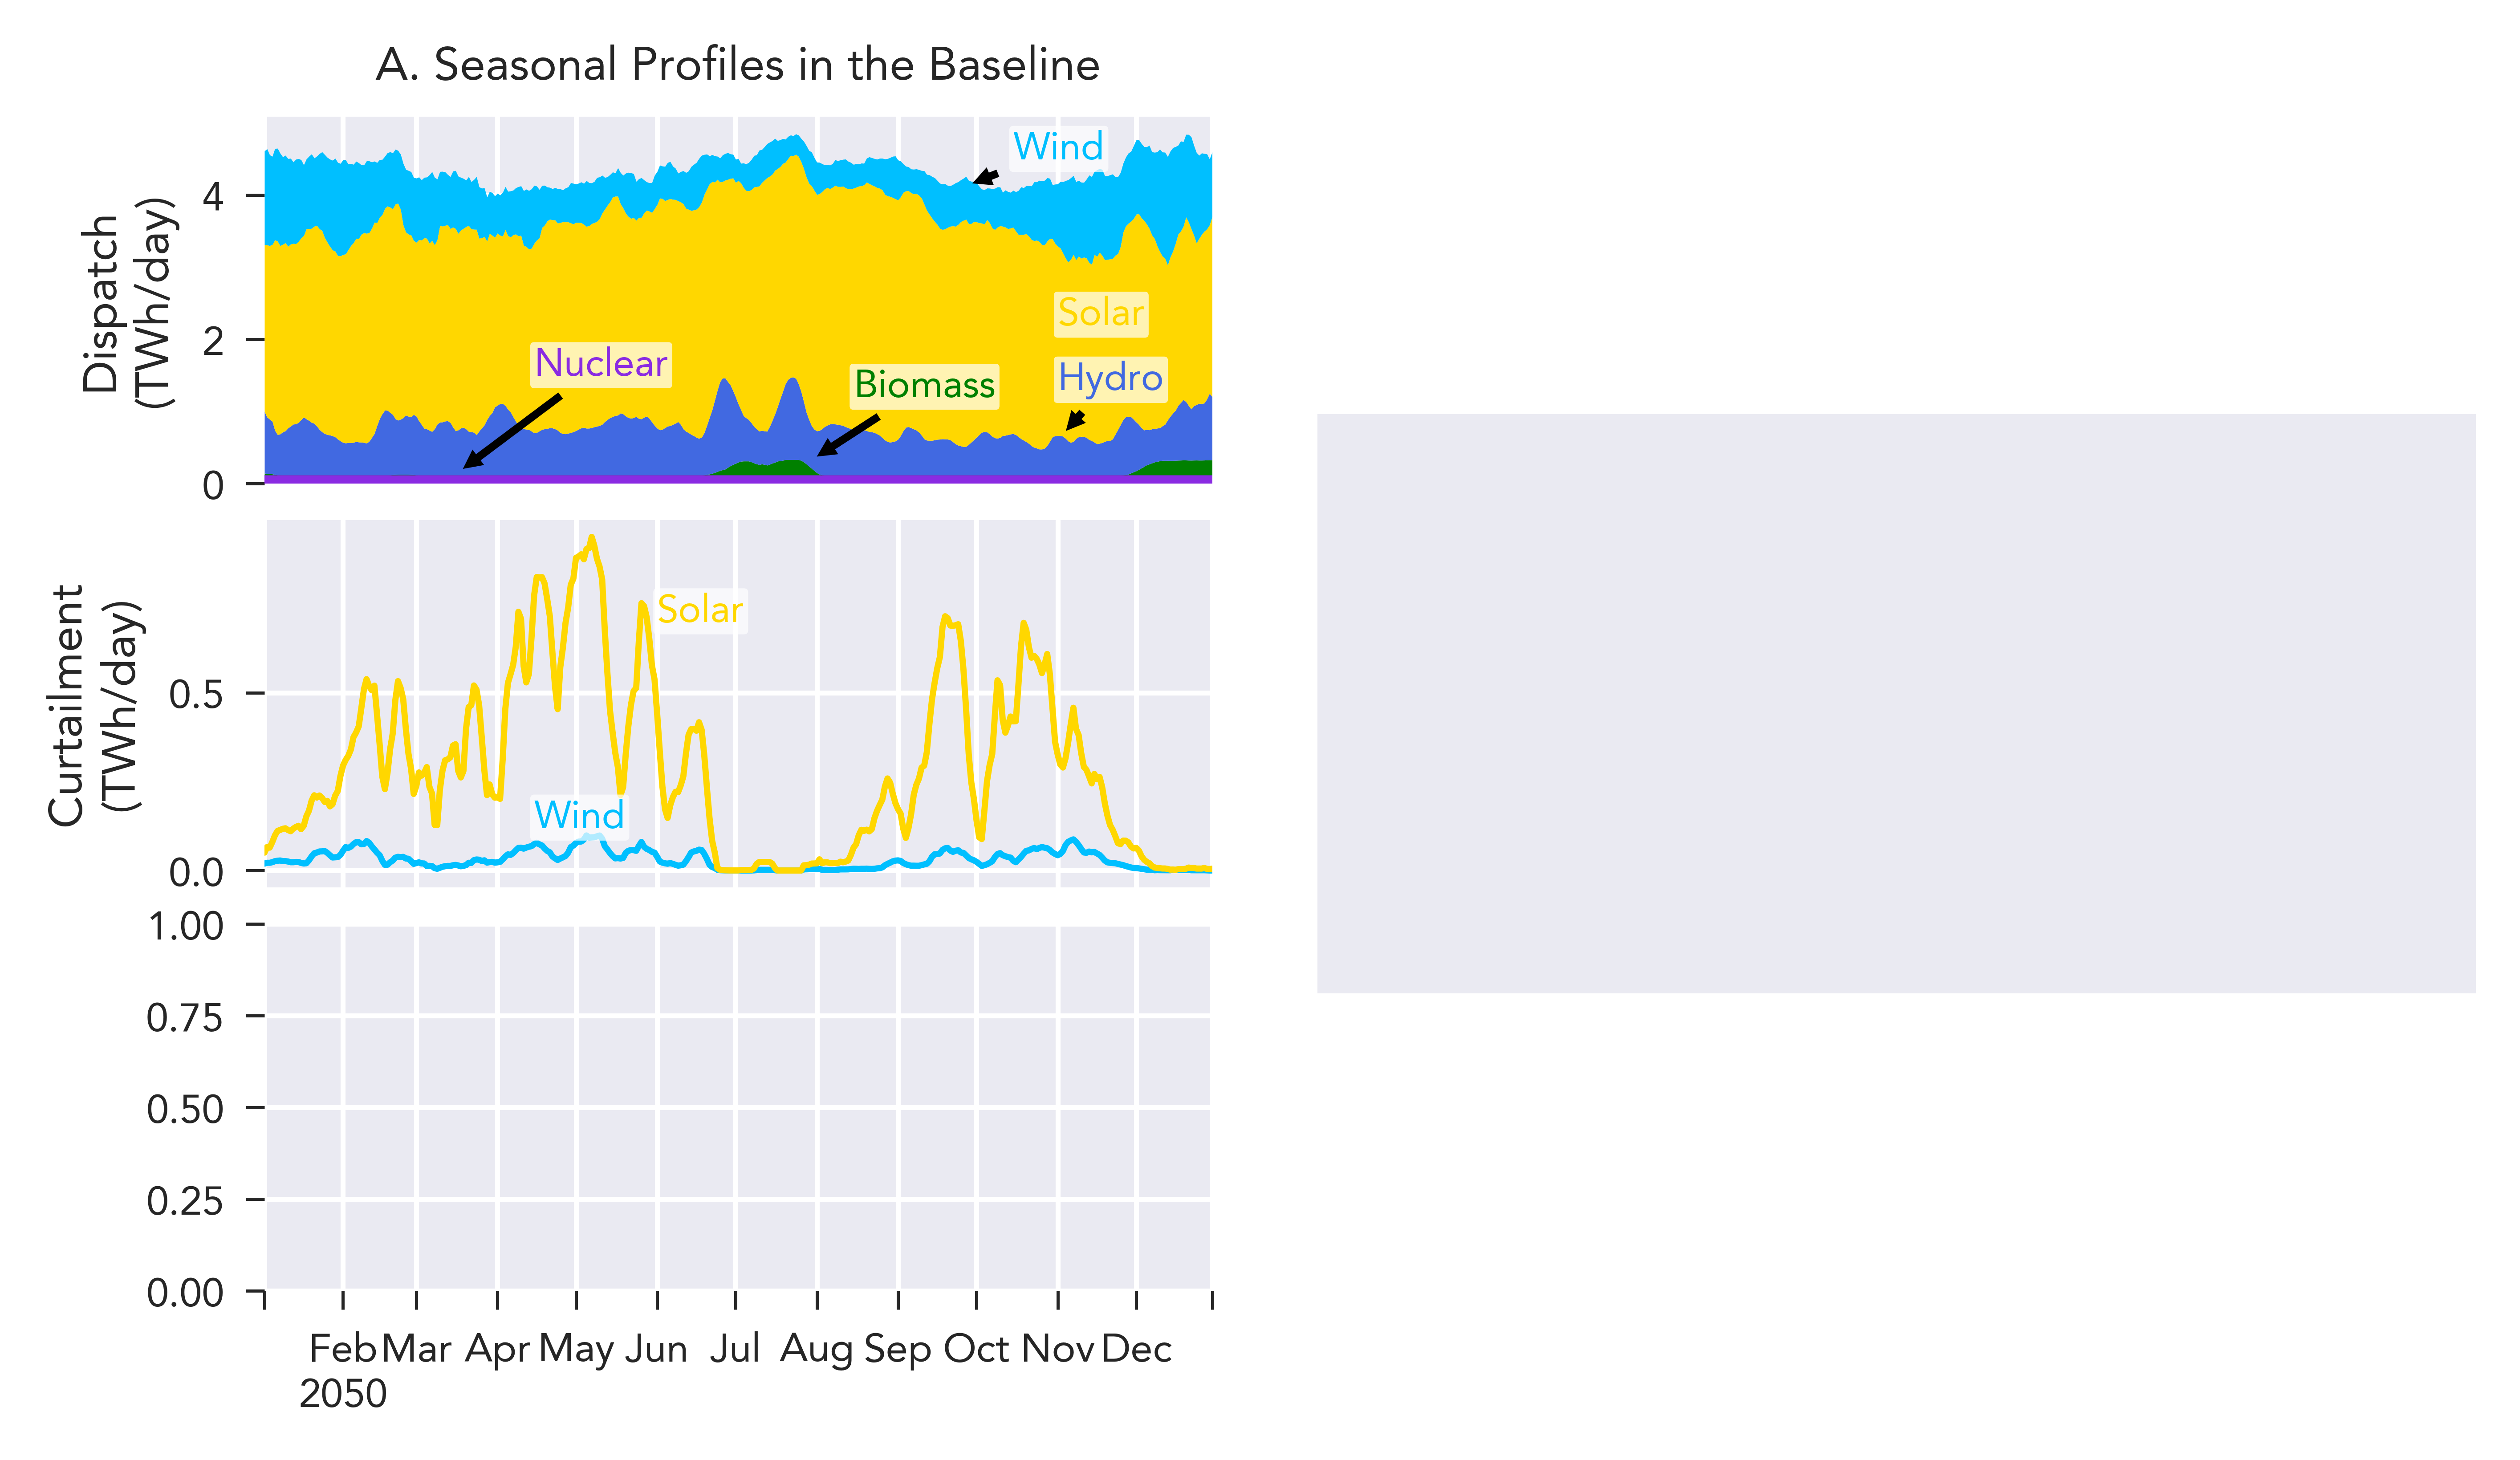

In [34]:
ax = ax1b
ax.clear()
curtailment.plot(ax=ax, color=tools.get_colors(), legend=False)
ax.set_ylabel("Curtailment\n(TWh/day)")
bbox = dict(pad=0.1, color="white", alpha=0.7, linewidth=0, boxstyle="round")
ax.annotate(text="Solar", color=tools.get_colors()["Solar"], fontsize="small", xy=(datetime(2050, 6, 1), 0.7),
            bbox=bbox)
ax.annotate(text="Wind", color=tools.get_colors()["Wind"], fontsize="small", xy=(datetime(2050, 4, 15), 0.12),
            bbox=bbox)
fig


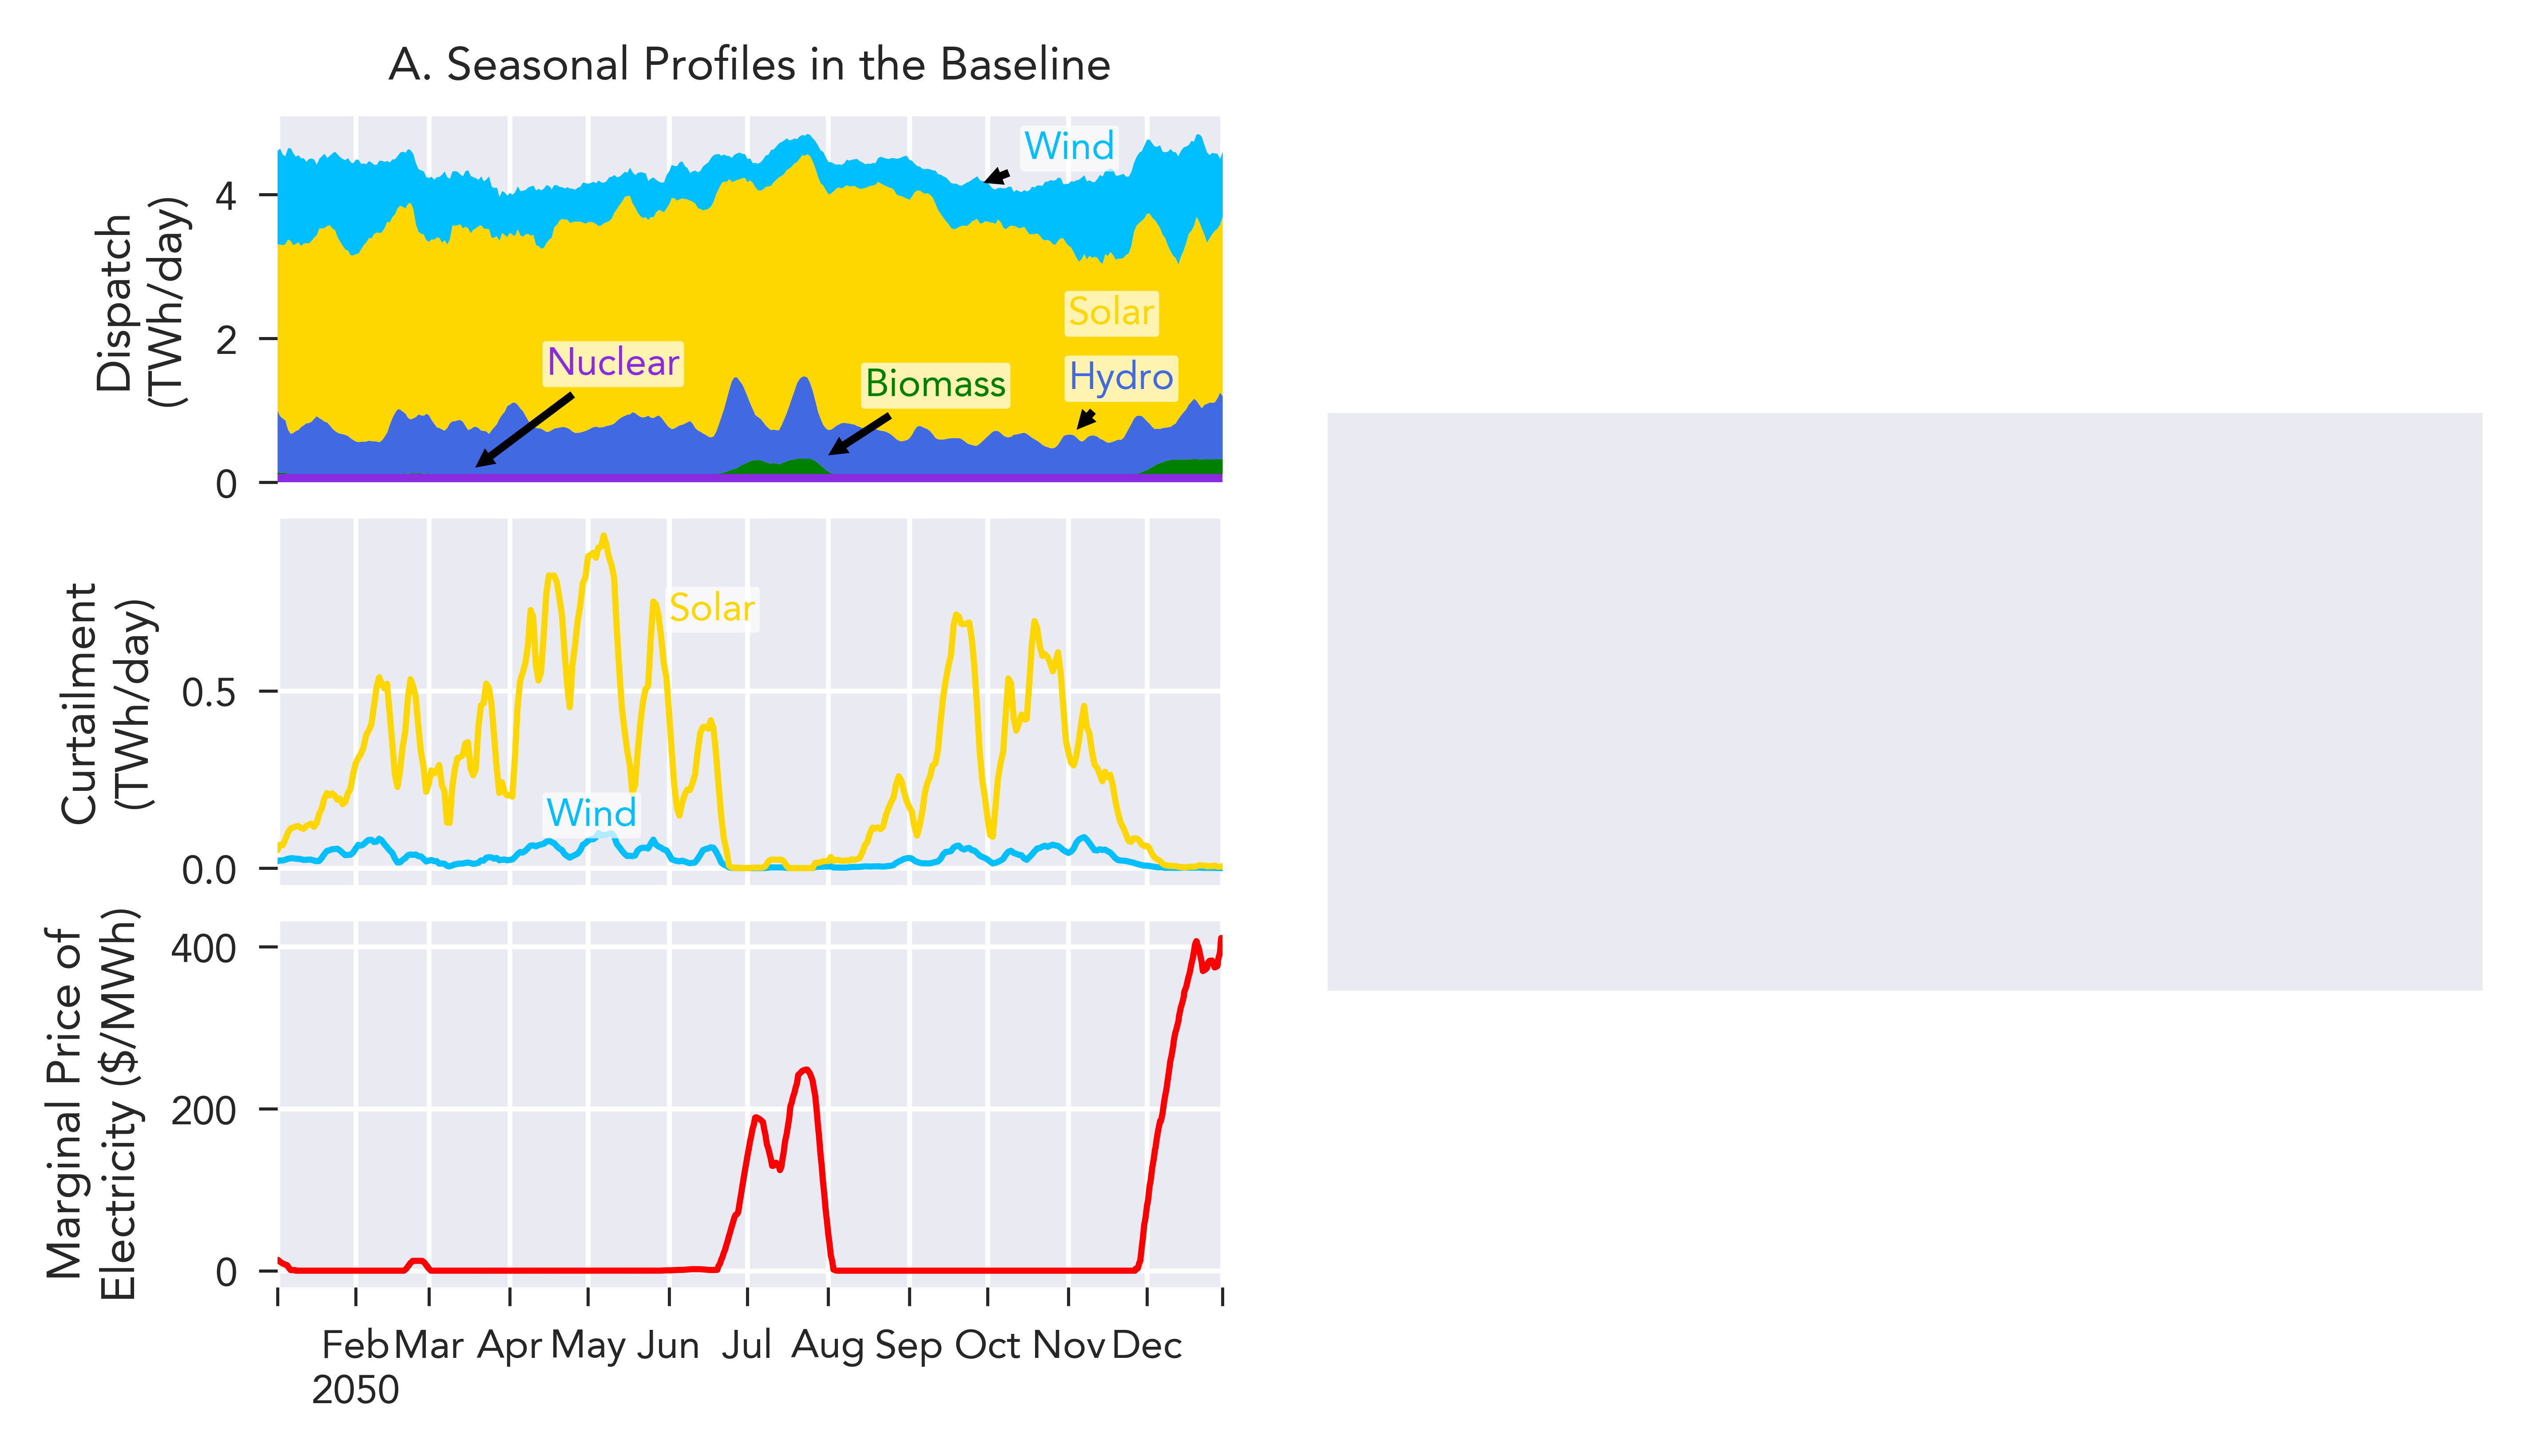

In [35]:
ax1c.plot(duals.index, duals.value, color="red")
ax1c.set_ylabel(u"Marginal Price of\nElectricity ($/MWh)")

fig

In [36]:

# %% CALC BOTTOM PANEL DATA
# Get data for mapping code
capacity = tools.get_dataframe("gen_cap.csv").rename({"GenCapacity": "value"}, axis=1)
capacity = tools.transform.gen_type(capacity)
capacity = capacity.groupby(["gen_type", "gen_load_zone"], as_index=False)["value"].sum()
# capacity = capacity[capacity.value > 1e-3]  # Must have at least 1 kW of capacity
capacity.value *= 1e-3  # Convert to GW

transmission = tools.get_dataframe("transmission.csv", convert_dot_to_na=True).fillna(0)
transmission = transmission[transmission["PERIOD"] == 2050]
transmission = transmission.rename(
    {"trans_lz1": "from", "trans_lz2": "to"}, axis=1
)
newtx = transmission.copy()
transmission["value"] = transmission["TxCapacityNameplate"] - transmission["BuildTx"]
transmission = transmission[["from", "to", "value"]]
transmission = transmission[transmission.value != 0]
transmission.value *= 1e-3  # Convert to GW

newtx = newtx.rename({"BuildTx": "value"}, axis=1)
newtx = newtx[["from", "to", "value"]]
newtx = newtx[newtx.value != 0]
newtx.value *= 1e-3  # Convert to GW

duration = tools.get_dataframe("storage_capacity.csv", usecols=[
    "load_zone",
    "OnlineEnergyCapacityMWh",
    "OnlinePowerCapacityMW",
    "period"
]).rename({"load_zone": "gen_load_zone"}, axis=1)
duration = duration[duration["period"] == 2050].drop(columns="period")
duration = duration.groupby("gen_load_zone", as_index=False).sum()
duration["value"] = duration["OnlineEnergyCapacityMWh"] / duration["OnlinePowerCapacityMW"]
duration = duration[["gen_load_zone", "value"]]

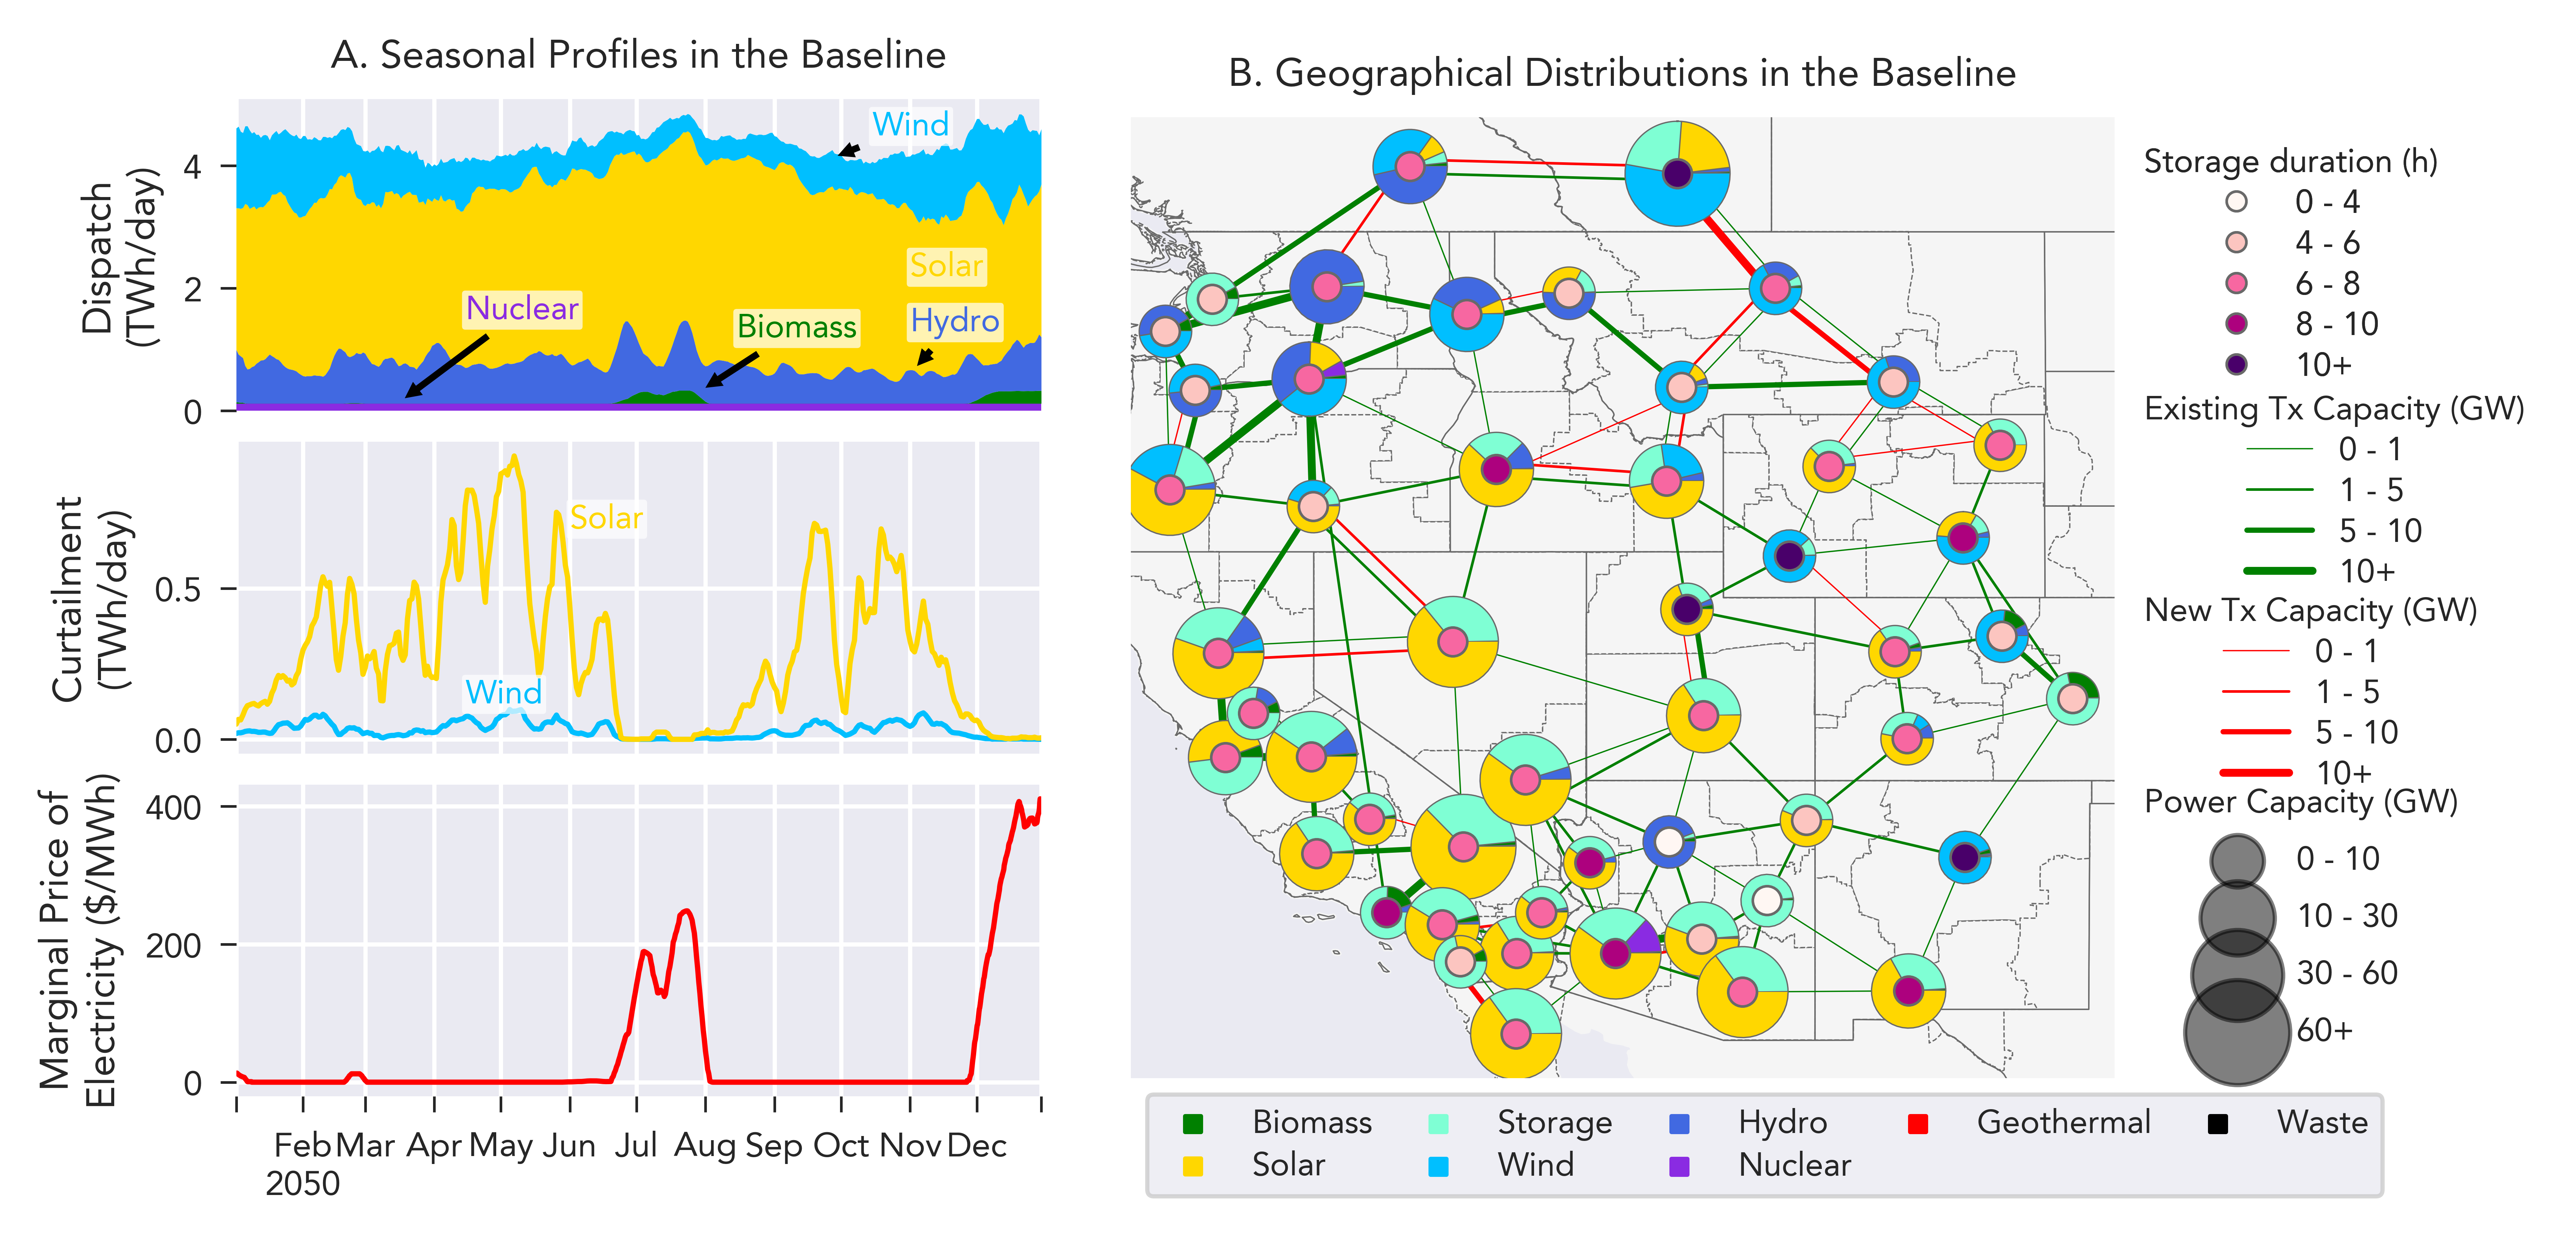

In [37]:

# %% PLOT BOTTOM PANEL
ax = ax2
ax.clear()
tools.maps.draw_base_map(ax)
skew_factor = 0.15

transmission["from_to"] = transmission["from"] + transmission["to"]
newtx["from_to"] = newtx["from"] + newtx["to"]
transmission_no_skew = transmission[~transmission.from_to.isin(newtx.from_to)]
transmission_with_skew = transmission[transmission.from_to.isin(newtx.from_to)]

tools.maps.graph_transmission_capacity(transmission_with_skew, ax=ax, legend=True, color="green", bbox_to_anchor=(1, 0.61),
                                       title="Existing Tx Capacity (GW)", skew_factor=-skew_factor)
tools.maps.graph_transmission_capacity(transmission_no_skew, ax=ax, legend=False, color="green", skew_factor=0)
tools.maps.graph_transmission_capacity(newtx, ax=ax, legend=True, color="red", bbox_to_anchor=(1, 0.4),
                                       title="New Tx Capacity (GW)", skew_factor=skew_factor)
capacity = capacity[(capacity.gen_type != "Coal") & (capacity.gen_type != "Gas")]
tools.maps.graph_pie_chart(capacity, ax=ax)
tools.maps.graph_duration(duration, ax=ax)
ax.set_title("B. Geographical Distributions in the Baseline")

fig

In [38]:
from papers.Martin_Staadecker_et_al_2022.util import save_figure

save_figure("figure-1-baseline.png")

In [39]:

# %% CALCULATIONS

# Panel A analysis
df = curtailment.copy()
df = df[["Solar"]]
df.columns = ["Curtailed"]

df2 = dispatch.copy()
df2 = df2[["Solar"]]
df2.columns = ["Total"]

df = df.join(df2)

df["Percent"] = (df.Curtailed - df.Total) / df.Total * 100
# ax1.plot(df["Percent"])
print("Max percent curtailed (%)", df.Percent.max())

Max percent curtailed (%) -66.88106025048197


In [40]:

# %%

df = duals
df = df.sort_values("value")
df = df[df.index.month != 12]  # Toggle to get value for mid year
# Inspect df to find maximum in each zone

# %%

In [41]:

df = dispatch.copy()
df["Nuclear"].unique() * 7

# %%

array([0.8201088])

In [42]:

df = dispatch.copy()
df = df["Hydro"] * 7
print(df.min())
print(df.max())

# %%

2.503147853944
8.912997943384399


In [43]:

df = curtailment.copy()
df_winter = df[(df.index.month <= 3) | (df.index.month >= 11)]
df_summer = df[~df.index.isin(df_winter.index)]
df_winter = df_winter.mean()
df_summer = df_summer.mean()
((df_winter / df_summer) - 1) * 100

# %%

gen_type
Wind    -11.852398
Solar   -37.811727
dtype: float64

In [44]:

# Get California stats
df = tools.get_dataframe("dispatch.csv")
df = tools.transform.gen_type(df)
df = df.groupby(["gen_load_zone", "gen_type"], as_index=False).sum()
df2 = df
# %%
# Get solar percent in generation
df = df2.copy()
df = tools.transform.load_zone(df, load_zone_col="gen_load_zone")
df_ca = df[df.region == "CA"]
df_ca = df_ca.groupby("gen_type")["DispatchGen_MW"].sum()
df_ca = df_ca[df_ca.index != "Storage"]

df_ca = df_ca / df_ca.sum()
df_ca

# %%

gen_type
Biomass       0.012382
Coal          0.000000
Gas           0.000000
Geothermal    0.000000
Hydro         0.061416
Solar         0.915093
Wind          0.011109
Name: DispatchGen_MW, dtype: float64

In [45]:
df = capacity.copy()
df = tools.transform.load_zone(df, load_zone_col="gen_load_zone")
df = df[df.region == "CA"]
df = df.groupby("gen_type").sum()
# df = (df / df.sum())
df
df = df[~df.index.isin(["Storage", "Solar"])]
df.sum()

# %%

value    17.043891
dtype: float64

In [46]:
df = capacity.copy()
southern_regions = ("CA", "NV", "UT", "CO", "AZ", "NM", "MEX")
df = tools.transform.load_zone(df, load_zone_col="gen_load_zone")
df = df.groupby(["region", "gen_type"], as_index=False).sum()
df_north = df[~df["region"].isin(southern_regions)]
df_north = df_north.groupby("gen_type").sum()
df = df.groupby("gen_type").sum()
df_north / df * 100

# %%

,value
gen_type,
Biomass,26.439777
Geothermal,NaN
Hydro,76.827268
Nuclear,22.182786
Solar,17.250973
Storage,16.035026
Waste,8.653846
Wind,91.126959


In [47]:
# Get load dataframe
df = tools.get_dataframe("load_balance.csv").rename({"zone_demand_mw": "value"}, axis=1)
df = tools.transform.load_zone(df)
df = df.groupby("region").value.sum() * -1
df_north = df[~df.index.isin(southern_regions)]
df_north.sum() / df.sum() * 100

# %%

41.1297614008129

In [48]:
df = tools.get_dataframe("transmission.csv", convert_dot_to_na=True).fillna(0)
df = df[df["PERIOD"] == 2050]
df = tools.transform.load_zone(df, load_zone_col="trans_lz1").rename({"region": "region_1"}, axis=1)
df = tools.transform.load_zone(df, load_zone_col="trans_lz2").rename({"region": "region_2"}, axis=1)
df.BuildTx *= df.trans_length_km
df.TxCapacityNameplate *= df.trans_length_km
df = df[["region_1", "region_2", "BuildTx", "TxCapacityNameplate"]]
df_north = df[(~df.region_1.isin(southern_regions)) & (~df.region_2.isin(southern_regions))]
df = df[df.region_1.isin(southern_regions) == df.region_2.isin(southern_regions)]
df = df[["BuildTx", "TxCapacityNameplate"]]
df_north = df_north[["BuildTx", "TxCapacityNameplate"]]
df_north = df_north.sum()
df = df.sum()
df_north / df

# %%

BuildTx                0.858623
TxCapacityNameplate    0.547085
dtype: float64

In [49]:
df = duration
df = df.sort_values(by="value")
df

# %%

,gen_load_zone,value
0,AZ_APS_E,3.606372
1,AZ_APS_N,3.643453
19,CA_SDGE,4.260831
31,MT_SW,4.260893
30,MT_SE,4.267551
45,WA_W,4.273514
37,OR_PDX,4.277400
21,CO_DEN,4.306054
29,MT_NW,4.626072
22,CO_E,4.938771


In [50]:
df = tools.get_dataframe("storage_capacity.csv")
df = df[df["period"] == 2050].drop(columns="period")
# df = df[df["load_zone"] != "CAN_ALB"]
# df = df.groupby("gen_load_zone", as_index=False).sum()
df["duration"] = df["OnlineEnergyCapacityMWh"] / df["OnlinePowerCapacityMW"]
df_long = df[df.duration > 10]
1 - df_long.OnlineEnergyCapacityMWh.sum() / df.OnlineEnergyCapacityMWh.sum()

0.8343810984014759

In [51]:

# %% BIOMASS PERCENT MAX USAGE
df = dispatch
df = df.join(load)
df["biomass_contr"] = df["Biomass"] / df["value"]
df = df["biomass_contr"]
df = df.sort_values(ascending=False)
df * 100

datetime
2050-12-28 00:00:00-08:00    4.809877
2050-12-29 00:00:00-08:00    4.790175
2050-12-27 00:00:00-08:00    4.777610
2050-12-30 00:00:00-08:00    4.760662
2050-12-26 00:00:00-08:00    4.751505
                               ...   
2050-08-10 00:00:00-08:00    0.024107
2050-08-11 00:00:00-08:00    0.024106
2050-01-11 00:00:00-08:00    0.024084
2050-02-17 00:00:00-08:00    0.023904
2050-02-18 00:00:00-08:00    0.023719
Name: biomass_contr, Length: 363, dtype: float64

In [52]:

# %% CALI DEMAND PEAK AND MEDIAN
# Get load dataframe
df = tools.get_dataframe(
    "load_balance.csv",
    usecols=["timestamp", "load_zone", "zone_demand_mw"],
).rename({"zone_demand_mw": "value"}, axis=1)
df = tools.transform.load_zone(df, load_zone_col="load_zone")
df = df[df.region == "CA"]
df = tools.transform.timestamp(df)
df = df.groupby("datetime").value.sum()
df *= -1e-3
df = df.sort_values()
df.mean()
# df


55.02661002426744